In [1]:
import sys
import os
import pandas as pd
from dotenv import load_dotenv  
from pathlib import Path

# if notebook is in PRIN/notebooks, parent() is PRIN
#project_root = Path.cwd().resolve().parent
#sys.path.insert(0, str(project_root))
#print("Added to sys.path:", project_root)

from constants import NAN_VALUE, AnnotationsReduced, AnnotatedReportReduced
from train_utils import create_list_of_annotated_reports
from model_utils import (
    get_binary_classification_fields,
    get_classification_fields,
    get_multiple_choice_fields,
    get_regression_fields
)

import json
from mistralai import Mistral
import time
from IPython.display import clear_output
from ast import literal_eval


In [2]:
# Parameters
TRAIN_FILE_NAME = "train_split_reduced.csv"
VALIDATION_FILE_NAME = "validation_split_reduced.csv"
TEST_FILE_NAME = "test_split_reduced.csv"

In [3]:
reg_fields = get_regression_fields(AnnotationsReduced)
cl_fields = get_classification_fields(AnnotationsReduced)
mc_fields = get_multiple_choice_fields(AnnotationsReduced)
bc_fields = get_binary_classification_fields(AnnotationsReduced)
print("Campi di regressione:", reg_fields)
print("Campi di classificazione:", cl_fields)
print("Campi di multi-scelta:", mc_fields)
print("Campi binari:", bc_fields)    

Campi di regressione: []
Campi di classificazione: ['morfologia', 'riflessione_peritoneale_anteriore', 'infiltrazione_tessuto_adiposo', 'stadio_T']
Campi di multi-scelta: ['posizione', 'infiltrazione_organi_dettagli', 'sedi_linfonodi']
Campi binari: ['infiltrazione_sfinteri', 'infiltrazione_organi_extra', 'coinvolgimento_riflessione_peritoneale', 'coinvolgimento_fascia_mesorettale', 'depositi_tumorali', 'emvi_esteso', 'stadio_N', 'stadio_N1c', 'mrf', 'emvi', 'metastasi']


In [4]:
# Carichiamo i nostri file csv
file_names = {
    'train': TRAIN_FILE_NAME,
    'validation': VALIDATION_FILE_NAME,
    'test': TEST_FILE_NAME,
}

paths = {
    split: Path('../data/' + file_name) for split, file_name in file_names.items()
}

data = dict()
for split, path in paths.items():
    data[split] = pd.read_csv(path).fillna(NAN_VALUE)
    
# Funzione per il parsing dei campi multi-scelta
#def parse_mc_field(value: str) -> list[str] | None:
#    return literal_eval(value)

#for split, df in data.items():
#    for field in mc_fields:
#        df[field] = df[field].apply(parse_mc_field)

train_data, validation_data, test_data = data['train'], data['validation'], data['test']

print(f"{len(train_data) = }")
print(f"{len(validation_data) = }")

len(train_data) = 166
len(validation_data) = 54


In [5]:
# Create lists of Annotated reports
annotated_reports =  {split: create_list_of_annotated_reports(data[split]) for split in data}

Now that we have loaded our dataset, we will convert it to the proper desired format to upload for training.

The data will be converted to a jsonl format as follows:

*THIS IS AN EXAMPLE*
```json
{"text": "Avena e nocciole cioccolato fondente", "labels": {"food": ["sweet-snacks"], "country_label": "italy"}}
{"text": "Pomodori in pezzi", "labels": {"food": ["plant-based-foods-and-beverages"], "country_label": "belgium"}}
{"text": "Grandyoats, Nori Sesame Cashews", "labels": {"food": ["snacks"], "country_label": "united-states"}}
{"text": "Jus d'orange Profit", "labels": {"food": ["beverages", "plant-based-foods-and-beverages"], "country_label": "switzerland"}}
{"text": "Rote Beete", "labels": {"food": ["plant-based-foods", "plant-based-foods-and-beverages"], "country_label": "germany"}}
...
```
With an example of a label being:
```json
"labels": {
  # Chekbox like sedi_linfonodi
  "food": [
    "beverages",
    "plant-based-foods-and-beverages"
  ],
  # Drop-down like morfologia
  "country_label": "switzerland"
}
```
For multi-target classification.

**WE CAN ONLY USE CATEGORICAL DATA**: no integers, no float.

Verranno esclusi i seguenti campi:
- ore inizio
- ore fine
- spessore parietale
- estensione cranio caudale
- distanza oai

Al momento escludiamo anche
- linfonodi sospetti
- numero depositi

anche se potrebbero essere discretizzati


In [6]:
def annotated_report_to_mistral_dict(annotated_report: AnnotatedReportReduced):
    result = {
        'text': annotated_report.report_text,
        'labels': dict()
    }
    for k, v in annotated_report.report_data.model_dump().items():
        # Value is boolean (flag)
        if isinstance(v, bool):
            result['labels'][k] = str(v)
            #result['labels'][k] = v
        # Value is a dict (check-box)
        #elif isinstance(v, dict):
        #    sub_list = []
        #    for kk, vv in v.items():
        #        if vv:
        #            sub_list.append(kk)
        #    result['labels'][k] = sub_list
        # Value is a string (drop-down)
        else:
            result['labels'][k] = v
    return result

In [7]:
mistral_data = dict()
for split, reports in annotated_reports.items():
    mistral_data[split] = [annotated_report_to_mistral_dict(report) for report in reports]

In [10]:
mistral_data['train'][0]['labels']

{'morfologia': 'solido_polipoide',
 'posizione': ['basso'],
 'riflessione_peritoneale_anteriore': 'NaN',
 'infiltrazione_tessuto_adiposo': 'no',
 'infiltrazione_sfinteri': 'False',
 'infiltrazione_organi_extra': 'False',
 'infiltrazione_organi_dettagli': [],
 'coinvolgimento_riflessione_peritoneale': 'False',
 'coinvolgimento_fascia_mesorettale': 'False',
 'sedi_linfonodi': ['mesorettali'],
 'depositi_tumorali': 'False',
 'emvi_esteso': 'False',
 'stadio_T': 'T1-2/NaN',
 'stadio_N': 'True',
 'stadio_N1c': 'False',
 'mrf': 'True',
 'emvi': 'True',
 'metastasi': 'True'}

In [11]:
# Save the formatted data as JSONL files
for split, mistral_reports in mistral_data.items():
    with open(f'{split}_mistral.jsonl', "w", encoding="utf-8") as f:
        for entry in mistral_reports:
            f.write(json.dumps(entry) + '\n')

print("JSONL files have been saved.")

JSONL files have been saved.


The data was converted and saved properly. We can now train our model.

## Training
There are two methods to train the model: either upload and train via [la platforme](https://console.mistral.ai/build/finetuned-models) or via the [API](https://classifier-factory.platform-docs-9m1.pages.dev/capabilities/finetuning/classifier_factory/).

First, we need to install `mistralai`.

In [68]:
# Set the API key for Mistral
load_dotenv()  # Load environment variables from .env file
mistral_api_key = os.getenv("MISTRAL_API_KEY")

# Set your Weights and Biases key
wandb_key = os.getenv("WANDB_API_KEY")

# Initialize the Mistral client
client = Mistral(api_key=mistral_api_key)

In [ ]:
if False:
    # Upload the training data
    training_data = client.files.upload(
        file={
            "file_name": "train_mistral.jsonl",
            "content": open("train_mistral.jsonl", "rb"),
        }
    )

    # Upload the validation data
    validation_data = client.files.upload(
        file={
            "file_name": "validation_mistral.jsonl",
            "content": open("validation_mistral.jsonl", "rb"),
        }
    )
    display(training_data.model_dump())
    display(validation_data.model_dump())

{'id': 'c62b8c08-c3a8-4f5f-a5e2-90607ef2763d',
 'object': 'file',
 'bytes': None,
 'created_at': 1767654458,
 'filename': 'train_mistral.jsonl',
 'purpose': 'fine-tune',
 'sample_type': 'classification',
 'source': 'upload',
 'num_lines': 166,
 'mimetype': 'application/jsonl',
 'signature': '885c4da82124de30'}

{'id': 'b6e474ad-be9a-43bf-bf69-dbb7b719034d',
 'object': 'file',
 'bytes': None,
 'created_at': 1767654459,
 'filename': 'validation_mistral.jsonl',
 'purpose': 'fine-tune',
 'sample_type': 'classification',
 'source': 'upload',
 'num_lines': 54,
 'mimetype': 'application/jsonl',
 'signature': '71f24b3fb38af969'}

In [77]:
res = client.files.list(page=0, page_size=100)
# Handle response
display(res.model_dump()['data'][0])
display(res.model_dump()['data'][1])

{'id': 'b6e474ad-be9a-43bf-bf69-dbb7b719034d',
 'object': 'file',
 'bytes': None,
 'created_at': 1767654459,
 'filename': 'validation_mistral.jsonl',
 'purpose': 'fine-tune',
 'sample_type': 'classification',
 'source': 'upload',
 'num_lines': 54,
 'mimetype': 'application/jsonl',
 'signature': '71f24b3fb38af969'}

{'id': 'c62b8c08-c3a8-4f5f-a5e2-90607ef2763d',
 'object': 'file',
 'bytes': None,
 'created_at': 1767654458,
 'filename': 'train_mistral.jsonl',
 'purpose': 'fine-tune',
 'sample_type': 'classification',
 'source': 'upload',
 'num_lines': 166,
 'mimetype': 'application/jsonl',
 'signature': '885c4da82124de30'}

With the data uploaded, we can create a job.

We allow users to keep track of aconsiderable amount of metrics via our Weights and Biases integration that we strongly recommend, you can make use of it by providing the project name and your key.

In [79]:
# Create a fine-tuning job
created_job = client.fine_tuning.jobs.create(
    model="ministral-3b-latest",
    job_type="classifier",
    training_files=[{"file_id": 'c62b8c08-c3a8-4f5f-a5e2-90607ef2763d', "weight": 1}],
    validation_files=['b6e474ad-be9a-43bf-bf69-dbb7b719034d'],
    hyperparameters={
        #"training_steps": 150,
        "epochs": 10,
        "learning_rate":0.0001
    },
    auto_start=False,
    integrations=[
        {
            "project": "PRIN",
            "api_key": wandb_key,
        }
    ]
)
print(json.dumps(created_job.model_dump(), indent=4))

{
    "id": "037d39cd-1d94-4dd5-b8f0-5f1026ee4914",
    "auto_start": false,
    "model": "ministral-3b-latest",
    "status": "QUEUED",
    "created_at": 1767658783,
    "modified_at": 1767658783,
    "training_files": [
        "c62b8c08-c3a8-4f5f-a5e2-90607ef2763d"
    ],
    "hyperparameters": {
        "training_steps": null,
        "learning_rate": 0.0001,
        "weight_decay": 0.1,
        "warmup_fraction": 0.05,
        "epochs": 10.0,
        "seq_len": 16384
    },
    "validation_files": [
        "b6e474ad-be9a-43bf-bf69-dbb7b719034d"
    ],
    "object": "job",
    "fine_tuned_model": null,
    "suffix": null,
    "integrations": [
        {
            "project": "PRIN",
            "type": "wandb",
            "name": null,
            "run_name": null,
            "url": null
        }
    ],
    "trained_tokens": null,
    "metadata": {
        "expected_duration_seconds": null,
        "cost": 0.0,
        "cost_currency": null,
        "train_tokens_per_step": nu

Once the job is created, we can review details such as the number of epochs and other relevant information. This allows us to make informed decisions before initiating the job.

We'll retrieve the job and wait for it to complete the validation process before starting. This validation step ensures the job is ready to begin.

In [80]:
# Retrieve the job details
retrieved_job = client.fine_tuning.jobs.get(job_id=created_job.id)
print(json.dumps(retrieved_job.model_dump(), indent=4))

# Wait for the job to be validated
while retrieved_job.status not in ["VALIDATED"]:
    retrieved_job = client.fine_tuning.jobs.get(job_id=created_job.id)

    clear_output(wait=True)  # Clear the previous output (User Friendly)
    print(json.dumps(retrieved_job.model_dump(), indent=4))
    time.sleep(1)

{
    "id": "037d39cd-1d94-4dd5-b8f0-5f1026ee4914",
    "auto_start": false,
    "model": "ministral-3b-latest",
    "status": "VALIDATED",
    "created_at": 1767658783,
    "modified_at": 1767658785,
    "training_files": [
        "c62b8c08-c3a8-4f5f-a5e2-90607ef2763d"
    ],
    "hyperparameters": {
        "training_steps": 48,
        "learning_rate": 0.0001,
        "weight_decay": 0.1,
        "warmup_fraction": 0.05,
        "epochs": 10.0,
        "seq_len": 16384
    },
    "classifier_targets": [
        {
            "name": "mrf",
            "labels": [
                "True",
                "False"
            ],
            "weight": 1.0,
            "loss_function": "single_class"
        },
        {
            "name": "emvi",
            "labels": [
                "True",
                "False"
            ],
            "weight": 1.0,
            "loss_function": "single_class"
        },
        {
            "name": "stadio_N",
            "labels": [
        

We can now run the job.

In [81]:
# Start the fine-tuning job
client.fine_tuning.jobs.start(job_id=created_job.id)
# Retrieve the job details again
retrieved_job = client.fine_tuning.jobs.get(job_id=created_job.id)

In [84]:
# Retrieve the job details again
retrieved_job = client.fine_tuning.jobs.get(job_id='037d39cd-1d94-4dd5-b8f0-5f1026ee4914')
print(json.dumps(retrieved_job.model_dump(), indent=4))

{
    "id": "037d39cd-1d94-4dd5-b8f0-5f1026ee4914",
    "auto_start": false,
    "model": "ministral-3b-latest",
    "status": "SUCCESS",
    "created_at": 1767658783,
    "modified_at": 1767658959,
    "training_files": [
        "c62b8c08-c3a8-4f5f-a5e2-90607ef2763d"
    ],
    "hyperparameters": {
        "training_steps": 48,
        "learning_rate": 0.0001,
        "weight_decay": 0.1,
        "warmup_fraction": 0.05,
        "epochs": 10.0,
        "seq_len": 16384
    },
    "classifier_targets": [
        {
            "name": "mrf",
            "labels": [
                "True",
                "False"
            ],
            "weight": 1.0,
            "loss_function": "single_class"
        },
        {
            "name": "emvi",
            "labels": [
                "True",
                "False"
            ],
            "weight": 1.0,
            "loss_function": "single_class"
        },
        {
            "name": "stadio_N",
            "labels": [
          

SUCCESS


C:\Users\lucat\AppData\Local\Temp\ipykernel_8348\2275632609.py:35: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  train_metrics_df = pd.concat(
C:\Users\lucat\AppData\Local\Temp\ipykernel_8348\2275632609.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  valid_metrics_df = pd.concat(


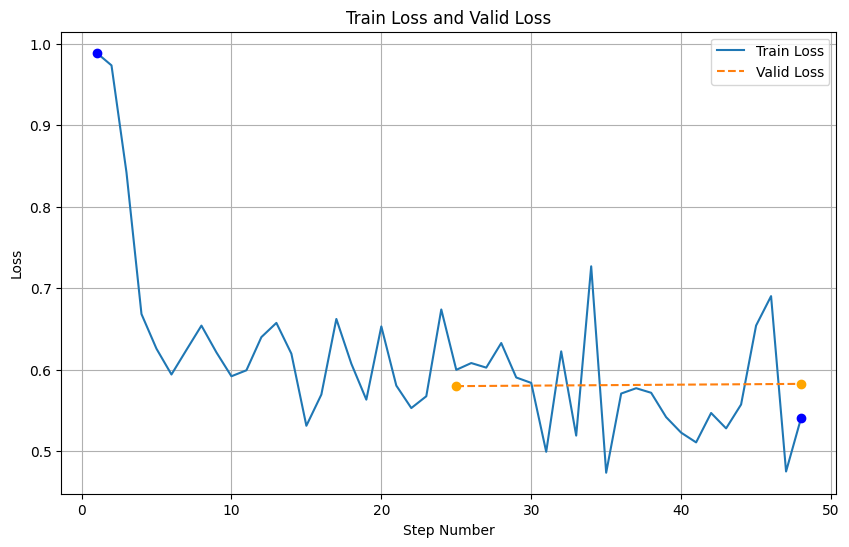

In [85]:
# @title Loss Plot
import pandas as pd
import time
import matplotlib.pyplot as plt
from IPython.display import clear_output

# Initialize DataFrames to store the metrics
train_metrics_df = pd.DataFrame(columns=["Step Number", "Train Loss"])
valid_metrics_df = pd.DataFrame(columns=["Step Number", "Valid Loss"])

# Total training steps
total_training_steps = retrieved_job.hyperparameters.training_steps

# Clear the previous output (User Friendly)
clear_output(wait=True)
print(retrieved_job.status)

# Extract metrics from all checkpoints
for checkpoint in retrieved_job.checkpoints[::-1]:
    metrics = checkpoint.metrics
    step_number = checkpoint.step_number

    # Check if the step number is already in the DataFrame
    if (
        step_number
        not in train_metrics_df["Step Number"]
    ):
        # Prepare the new row for train loss
        train_row = {
            "Step Number": step_number,
            "Train Loss": metrics.train_loss,
        }

        # Append the new train metrics to the DataFrame
        train_metrics_df = pd.concat(
            [train_metrics_df, pd.DataFrame([train_row])], ignore_index=True
        )

        # Prepare the new row for valid loss if available
        if metrics.valid_loss != 0:
            valid_row = {
                "Step Number": step_number,
                "Valid Loss": metrics.valid_loss,
            }
            # Append the new valid metrics to the DataFrame
            valid_metrics_df = pd.concat(
                [valid_metrics_df, pd.DataFrame([valid_row])], ignore_index=True
            )

if len(retrieved_job.checkpoints) > 0:
    # Sort the DataFrames by step number
    train_metrics_df = train_metrics_df.sort_values(by="Step Number")
    valid_metrics_df = valid_metrics_df.sort_values(by="Step Number")

    # Plot the evolution of train loss and valid loss
    plt.figure(figsize=(10, 6))

    # Plot train loss
    plt.plot(
        train_metrics_df["Step Number"],
        train_metrics_df["Train Loss"],
        label="Train Loss",
        linestyle="-",
    )

    # Highlight start and end points of train loss
    plt.scatter(
        train_metrics_df.iloc[[0, -1]]["Step Number"],
        train_metrics_df.iloc[[0, -1]]["Train Loss"],
        color="blue",
        zorder=5,
    )

    # Plot valid loss only if available
    if not valid_metrics_df.empty:
        plt.plot(
            valid_metrics_df["Step Number"],
            valid_metrics_df["Valid Loss"],
            label="Valid Loss",
            linestyle="--",
        )

        # Highlight start and end points of valid loss
        plt.scatter(
            valid_metrics_df.iloc[[0, -1]]["Step Number"],
            valid_metrics_df.iloc[[0, -1]]["Valid Loss"],
            color="orange",
            zorder=5,
        )

    plt.xlabel("Step Number")
    plt.ylabel("Loss")
    plt.title("Train Loss and Valid Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

time.sleep(1)